<a href="https://colab.research.google.com/github/Best-Verie/sa_waste_linearRegression/blob/main/Summative_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


(1564, 7)
Index(['Year', 'Province', 'Number of Facilities', 'General Waste (t)',
       'Hazardous Waste (t)', 'Total Tonnage (t)', 'Unnamed: 6'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1564 entries, 0 to 1563
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  155 non-null    float64
 1   Province              155 non-null    object 
 2   Number of Facilities  155 non-null    float64
 3   General Waste (t)     155 non-null    object 
 4   Hazardous Waste (t)   155 non-null    object 
 5   Total Tonnage (t)     155 non-null    object 
 6   Unnamed: 6            0 non-null      float64
dtypes: float64(3), object(4)
memory usage: 85.7+ KB
None
              Year  Number of Facilities  Unnamed: 6
count   155.000000            155.000000         0.0
mean   2015.503226             68.238710         NaN
std       5.592637            220.075668        

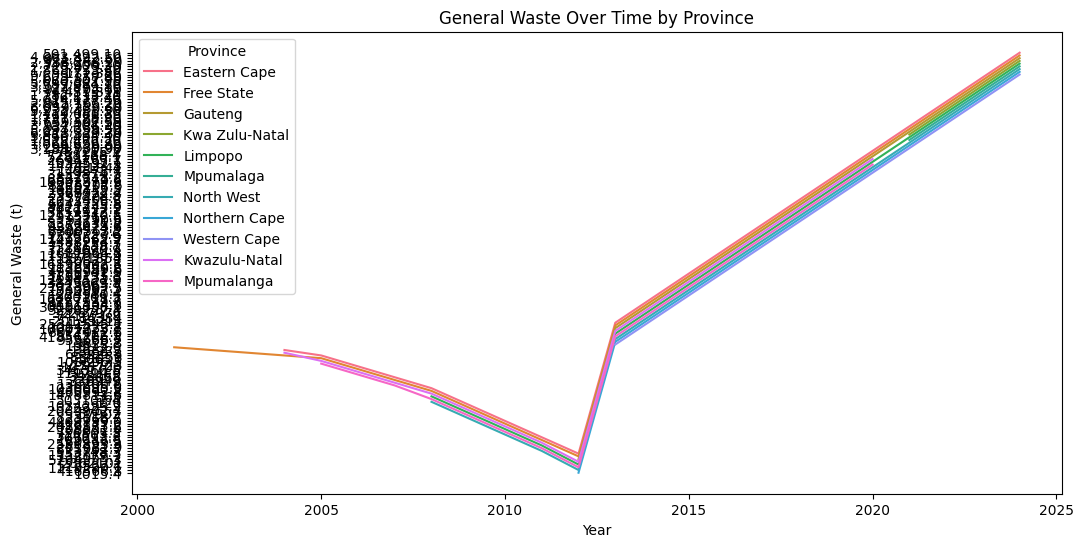

In [2]:
import pandas as pd

file_path = '/content/drive/MyDrive/Datasets/South_African_Waste_Data.csv'  # <-- change this
df = pd.read_csv(file_path)

# Quick look
print(df.shape)
print(df.columns)
df.head()


print(df.info())
print(df.describe())
print(df.isnull().sum())
print(df['Province'].unique())

# Visualize General Waste trends by Province
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))
sns.lineplot(data=df, x="Year", y="General Waste (t)", hue="Province")
plt.title("General Waste Over Time by Province")
plt.show()

In [3]:
# Drop rows with NaN values in the relevant columns
df = df.dropna(subset=['Year', 'Number of Facilities', 'General Waste (t)', 'Hazardous Waste (t)'])

# Remove 'Unnamed: 6' column as it contains only NaN values
df = df.drop(columns=['Unnamed: 6'])

# Remove commas and convert numeric columns
numeric_cols = ['Number of Facilities', 'General Waste (t)', 'Hazardous Waste (t)']

for col in numeric_cols:
    # Convert to string first to handle potential mixed types before applying .str
    df[col] = df[col].astype(str).str.replace(',', '', regex=False)  # remove commas
    df[col] = df[col].astype(float)         # convert to float


# Drop derived column
df = df.drop(columns=['Total Tonnage (t)'])

# Encode Province (One-Hot)
df = pd.get_dummies(df, columns=['Province'], drop_first=True)

# Split features and target
X = df.drop(columns=['Hazardous Waste (t)'])
y = df['Hazardous Waste (t)']

#  Train-test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Check types to confirm
print(X_train.dtypes)
print(y_train.dtype)

Year                       float64
Number of Facilities       float64
General Waste (t)          float64
Province_Free State           bool
Province_Gauteng              bool
Province_Kwa Zulu-Natal       bool
Province_Kwazulu-Natal        bool
Province_Limpopo              bool
Province_Mpumalaga            bool
Province_Mpumalanga           bool
Province_North West           bool
Province_Northern Cape        bool
Province_Western Cape         bool
dtype: object
float64


In [4]:
# Traditional Machine Learning Models
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



In [16]:
def run_traditional_ml_experiments(X_train, X_test, y_train, y_test):
    """
    Runs 4 traditional ML experiments and returns a summary dataframe:
    - Linear Regression
    - Decision Tree
    - Random Forest
    - Gradient Boosting
    """
    results = []
    models = {
        "Linear Regression": LinearRegression(),
        "Decision Tree": DecisionTreeRegressor(max_depth=5, random_state=42),
        "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
        "Gradient Boosting": GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
    }

    for name, model in models.items():
        # --- Train ---
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        # --- Evaluate ---
        mae = mean_absolute_error(y_test, y_pred)
        # Calculate RMSE by taking the square root of the mean squared error
        rmse = mean_squared_error(y_test, y_pred) ** 0.5
        r2 = r2_score(y_test, y_pred)

        results.append({
            "Model": name,
            "MAE": mae,
            "RMSE": rmse,
            "R²": r2
        })

        # --- Visualization ---
        plt.figure(figsize=(6, 5))
        plt.scatter(y_test, y_pred, alpha=0.7)
        plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
        plt.title(f"{name}: Actual vs Predicted")
        plt.xlabel("Actual Hazardous Waste (t)")
        plt.ylabel("Predicted Hazardous Waste (t)")
        plt.show()

        # --- Feature importance (for tree-based models only) ---
        if hasattr(model, "feature_importances_"):
            feat_importances = model.feature_importances_
            fi_df = pd.DataFrame({
                "Feature": X_train.columns,
                "Importance": feat_importances
            }).sort_values("Importance", ascending=True)

            plt.figure(figsize=(8, 6))
            sns.barplot(x="Importance", y="Feature", data=fi_df)
            plt.title(f"Feature Importance - {name}")
            plt.show()

    # --- Summary dataframe ---
    results_df = pd.DataFrame(results)
    results_df = results_df.sort_values("RMSE", ascending=True).reset_index(drop=True)
    print("All Traditional experiments completed successfully.")
    return results_df

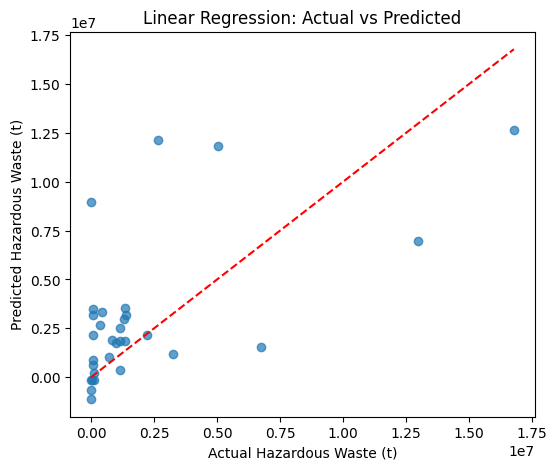

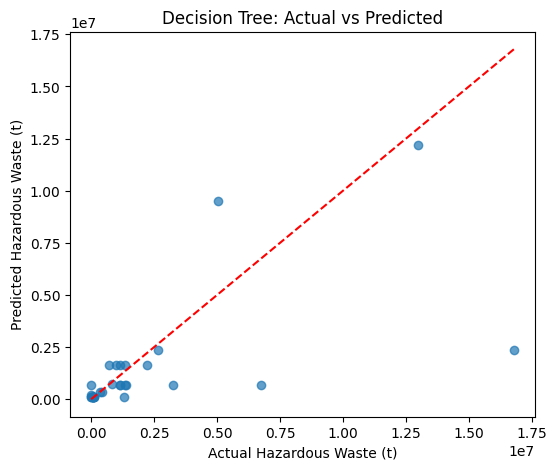

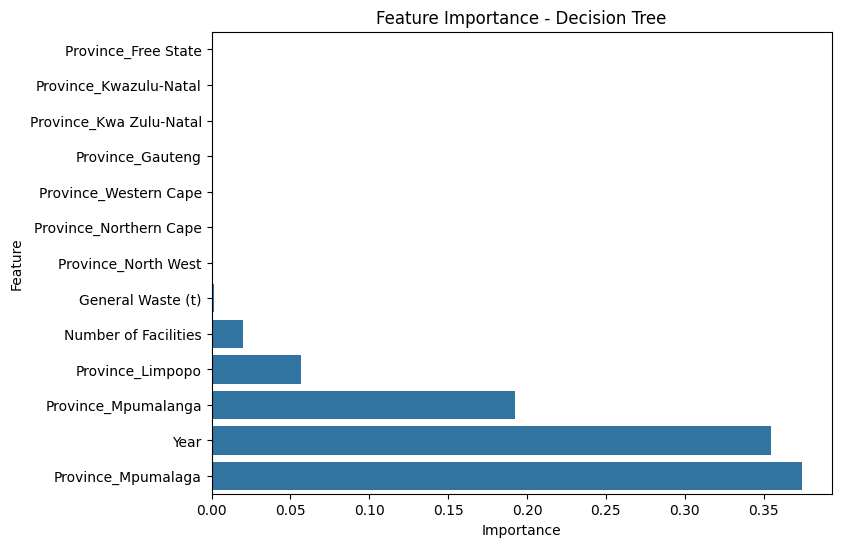

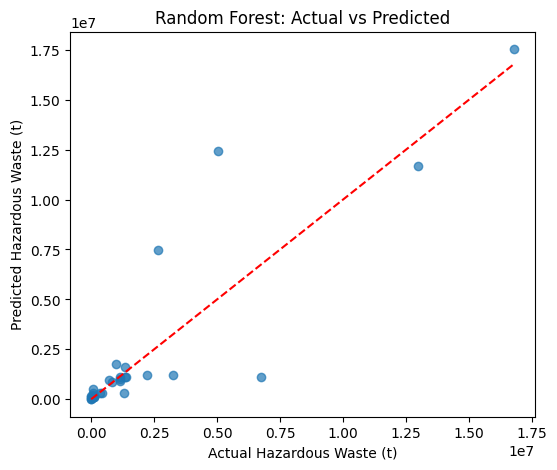

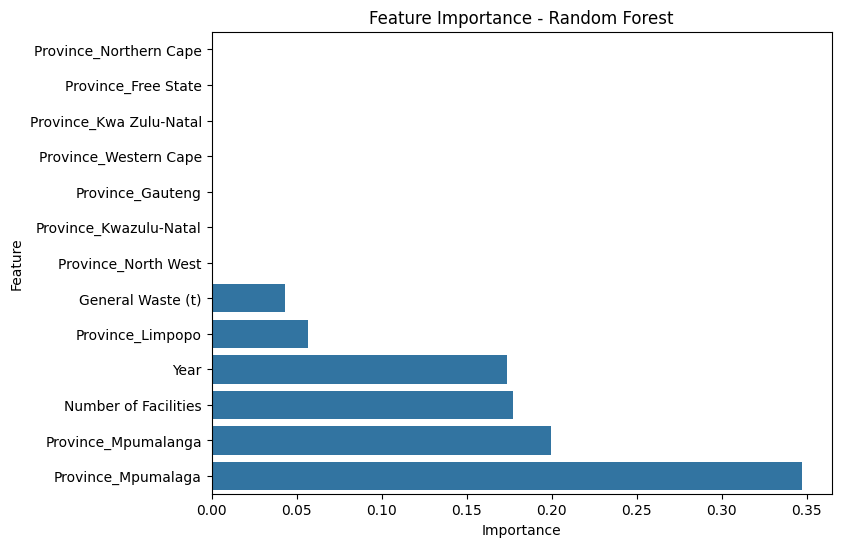

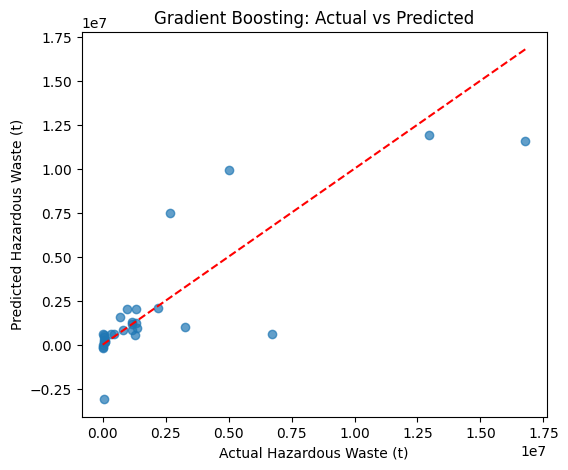

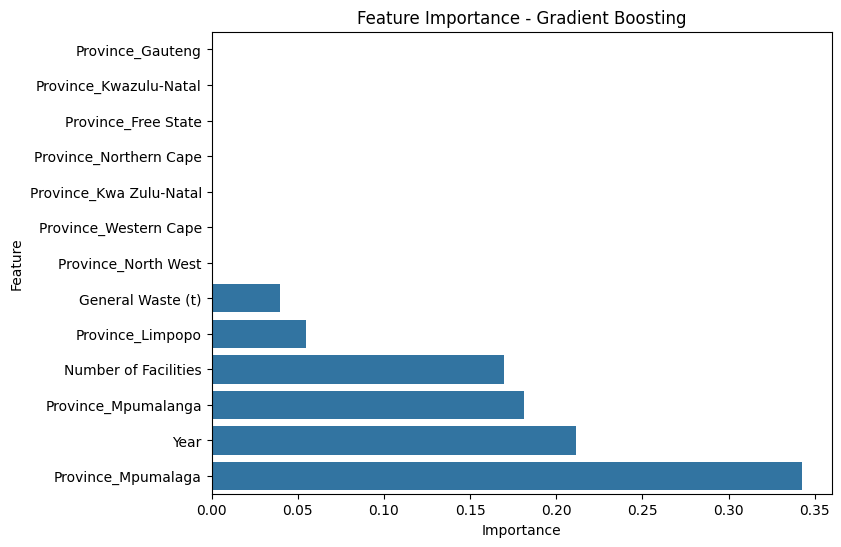

All Traditional experiments completed successfully.


In [17]:
results_df = run_traditional_ml_experiments(X_train, X_test, y_train, y_test)


In [18]:
#Modern

import tensorflow as tf
from tensorflow.keras import layers, models, Input
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.optimizers import Adam, RMSprop
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import pandas as pd


In [19]:
# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Create tf.data Datasets
train_ds = tf.data.Dataset.from_tensor_slices((X_train_scaled, y_train)).batch(16).shuffle(100)
test_ds = tf.data.Dataset.from_tensor_slices((X_test_scaled, y_test)).batch(16)


In [20]:
def build_baseline_model(input_dim):
    model = Sequential([
        layers.Dense(64, activation='relu', input_shape=(input_dim,)),
        layers.Dense(1)
    ])
    model.compile(optimizer=Adam(0.001), loss='mse', metrics=['mae'])
    return model

baseline_model = build_baseline_model(X_train_scaled.shape[1])
history1 = baseline_model.fit(train_ds, validation_data=test_ds, epochs=100, verbose=0)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


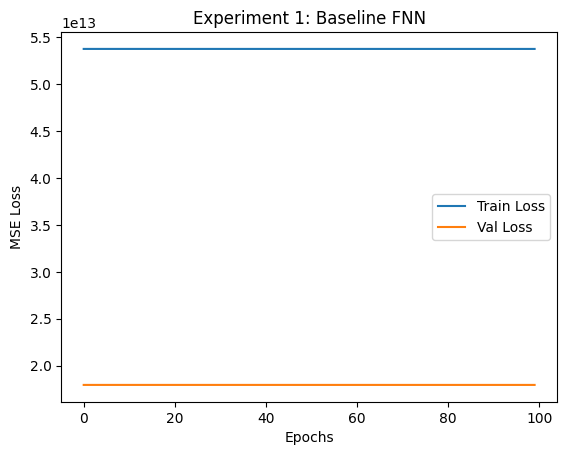

In [21]:
plt.plot(history1.history['loss'], label='Train Loss')
plt.plot(history1.history['val_loss'], label='Val Loss')
plt.title("Experiment 1: Baseline FNN")
plt.xlabel("Epochs")
plt.ylabel("MSE Loss")
plt.legend()
plt.show()


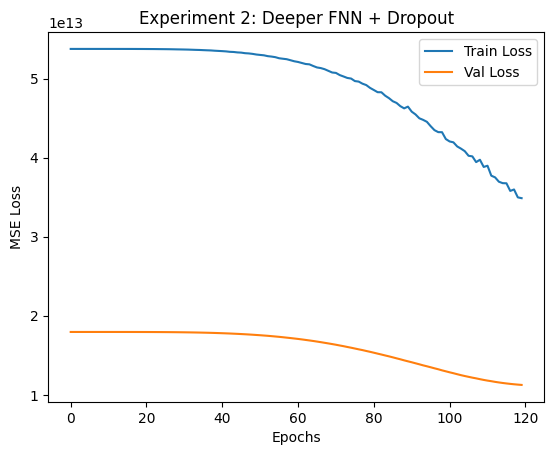

In [22]:
def build_deep_model(input_dim):
    model = Sequential([
        layers.Dense(128, activation='relu', input_shape=(input_dim,)),
        layers.Dropout(0.3),
        layers.Dense(64, activation='relu'),
        layers.Dense(32, activation='relu'),
        layers.Dense(1)
    ])
    model.compile(optimizer=Adam(0.001), loss='mse', metrics=['mae'])
    return model

deep_model = build_deep_model(X_train_scaled.shape[1])
history2 = deep_model.fit(train_ds, validation_data=test_ds, epochs=120, verbose=0)

plt.plot(history2.history['loss'], label='Train Loss')
plt.plot(history2.history['val_loss'], label='Val Loss')
plt.title("Experiment 2: Deeper FNN + Dropout")
plt.xlabel("Epochs")
plt.ylabel("MSE Loss")
plt.legend()
plt.show()


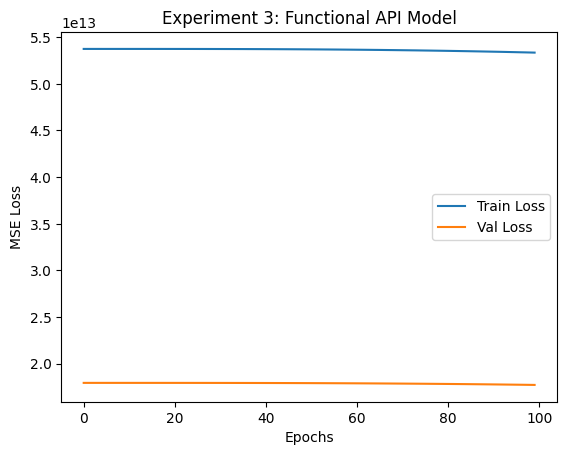

In [23]:
def build_functional_model(input_dim):
    inputs = Input(shape=(input_dim,))
    x = layers.Dense(128, activation='relu')(inputs)
    x1 = layers.Dense(64, activation='relu')(x)
    x2 = layers.Dense(32, activation='relu')(x)
    concat = layers.Concatenate()([x1, x2])
    outputs = layers.Dense(1)(concat)
    model = Model(inputs, outputs)
    model.compile(optimizer=Adam(0.001), loss='mse', metrics=['mae'])
    return model

func_model = build_functional_model(X_train_scaled.shape[1])
history3 = func_model.fit(train_ds, validation_data=test_ds, epochs=100, verbose=0)

plt.plot(history3.history['loss'], label='Train Loss')
plt.plot(history3.history['val_loss'], label='Val Loss')
plt.title("Experiment 3: Functional API Model")
plt.xlabel("Epochs")
plt.ylabel("MSE Loss")
plt.legend()
plt.show()


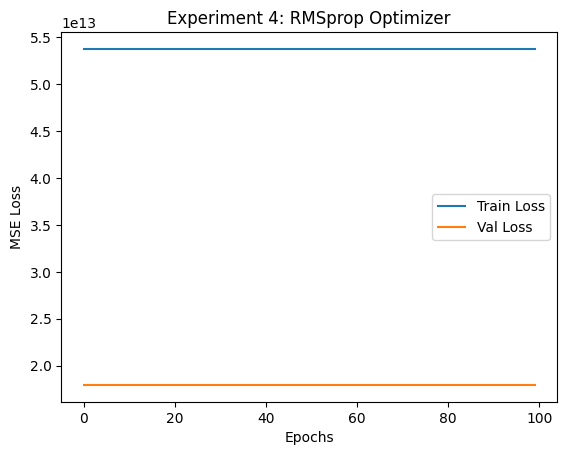

In [24]:
def build_rmsprop_model(input_dim):
    model = Sequential([
        layers.Dense(128, activation='tanh', input_shape=(input_dim,)),
        layers.Dense(64, activation='tanh'),
        layers.Dense(1)
    ])
    model.compile(optimizer=RMSprop(learning_rate=0.0005), loss='mse', metrics=['mae'])
    return model

rms_model = build_rmsprop_model(X_train_scaled.shape[1])
history4 = rms_model.fit(train_ds, validation_data=test_ds, epochs=100, verbose=0)

plt.plot(history4.history['loss'], label='Train Loss')
plt.plot(history4.history['val_loss'], label='Val Loss')
plt.title("Experiment 4: RMSprop Optimizer")
plt.xlabel("Epochs")
plt.ylabel("MSE Loss")
plt.legend()
plt.show()


In [27]:
import numpy as np
def evaluate_dl_model(model, X_test, y_test, name):
    preds = model.predict(X_test_scaled).flatten()
    mae = mean_absolute_error(y_test, preds)
    # Calculate RMSE by taking the square root of the mean squared error
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)
    return {"Model": name, "MAE": mae, "RMSE": rmse, "R²": r2}

dl_results = [
    evaluate_dl_model(baseline_model, X_test_scaled, y_test, "FNN Baseline"),
    evaluate_dl_model(deep_model, X_test_scaled, y_test, "FNN Deep + Dropout"),
    evaluate_dl_model(func_model, X_test_scaled, y_test, "Functional API FNN"),
    evaluate_dl_model(rms_model, X_test_scaled, y_test, "RMSprop FNN"),
]

dl_results_df = pd.DataFrame(dl_results)
dl_results_df.sort_values("RMSE", ascending=True).reset_index(drop=True)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step


,Model,MAE,RMSE,R²
0,FNN Deep + Dropout,2.067615e+06,3.354868e+06,0.191188
1,Functional API FNN,1.981317e+06,4.211074e+06,-0.274331
2,FNN Baseline,2.009034e+06,4.236931e+06,-0.290029
3,RMSprop FNN,2.009095e+06,4.236993e+06,-0.290067


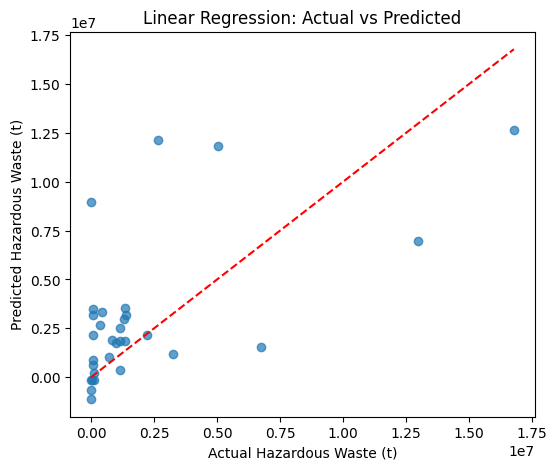

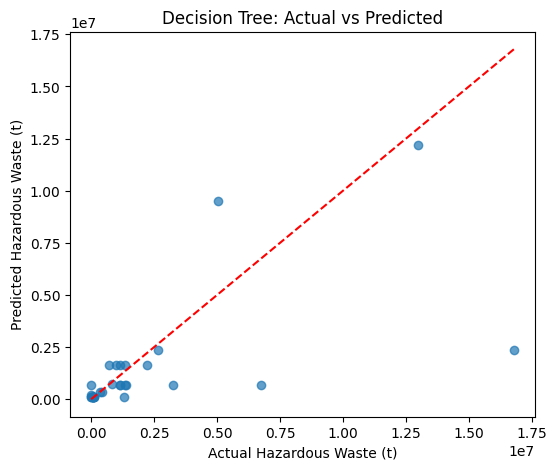

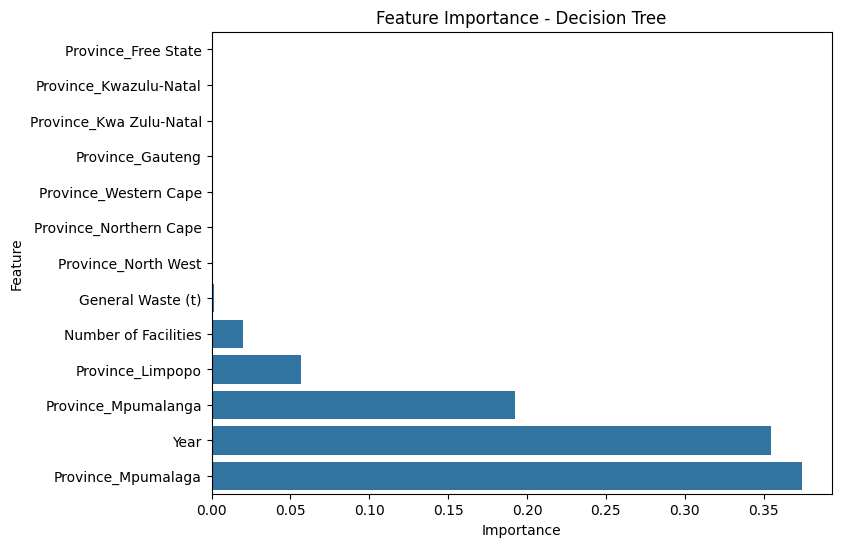

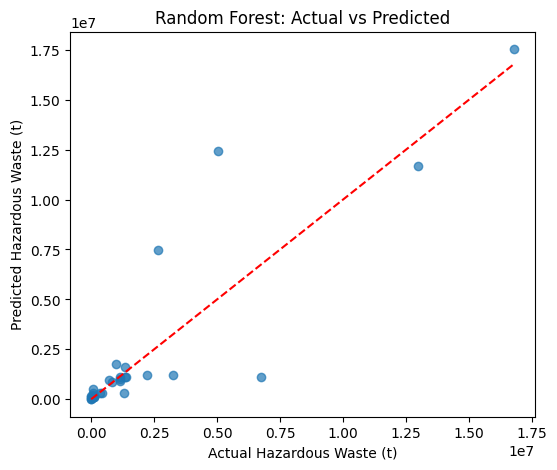

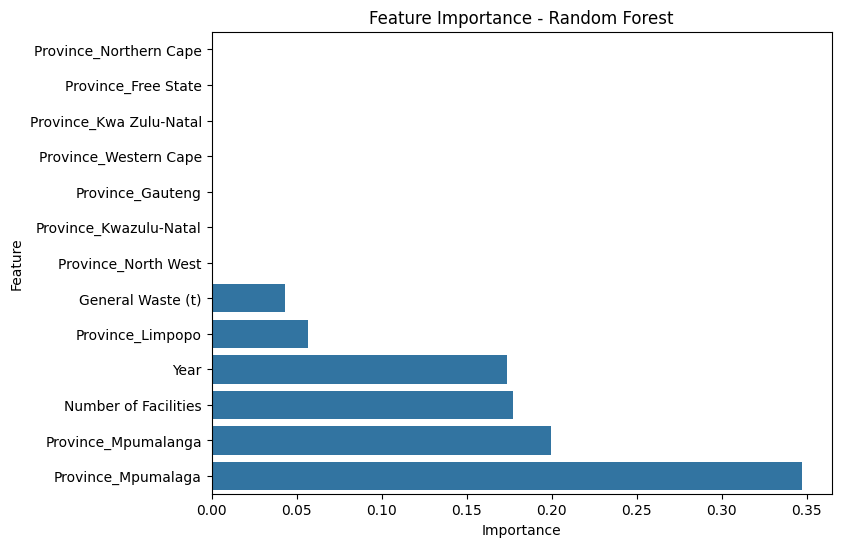

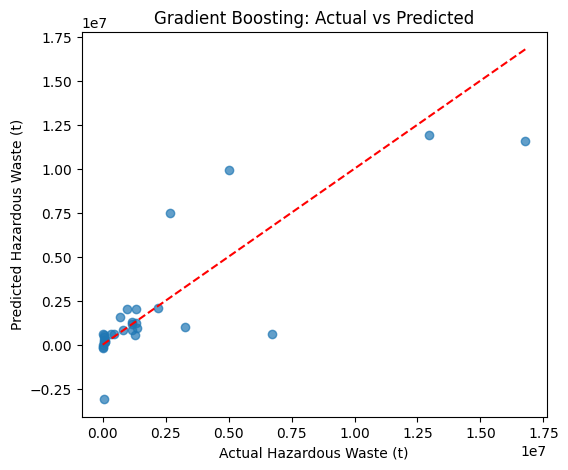

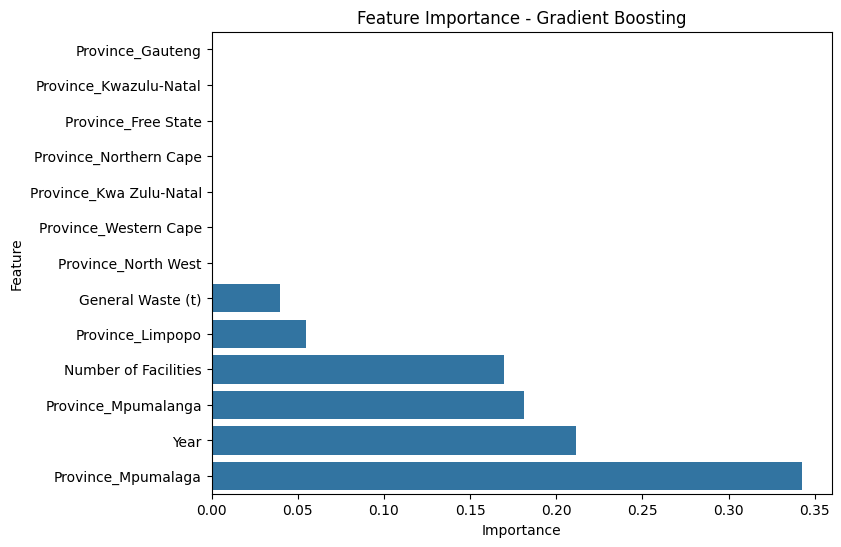

All Traditional experiments completed successfully.


In [29]:
results_df = run_traditional_ml_experiments(X_train, X_test, y_train, y_test)


In [30]:
dl_results_df = pd.DataFrame(dl_results)


In [31]:
# Add a column to distinguish the model type
results_df['Category'] = 'Traditional ML'
dl_results_df['Category'] = 'Deep Learning'

# Combine into a single DataFrame
final_results = pd.concat([results_df, dl_results_df], ignore_index=True)

# Sort by RMSE
final_results = final_results.sort_values(by='RMSE', ascending=True).reset_index(drop=True)
final_results


,Model,MAE,RMSE,R²,Category
0,Random Forest,8.915474e+05,1.964432e+06,0.722687,Traditional ML
1,Gradient Boosting,1.127460e+06,2.062432e+06,0.694328,Traditional ML
2,Decision Tree,1.179440e+06,2.992135e+06,0.356633,Traditional ML
3,FNN Deep + Dropout,2.067615e+06,3.354868e+06,0.191188,Deep Learning
4,Linear Regression,2.309171e+06,3.404074e+06,0.167289,Traditional ML
5,Functional API FNN,1.981317e+06,4.211074e+06,-0.274331,Deep Learning
6,FNN Baseline,2.009034e+06,4.236931e+06,-0.290029,Deep Learning
7,RMSprop FNN,2.009095e+06,4.236993e+06,-0.290067,Deep Learning


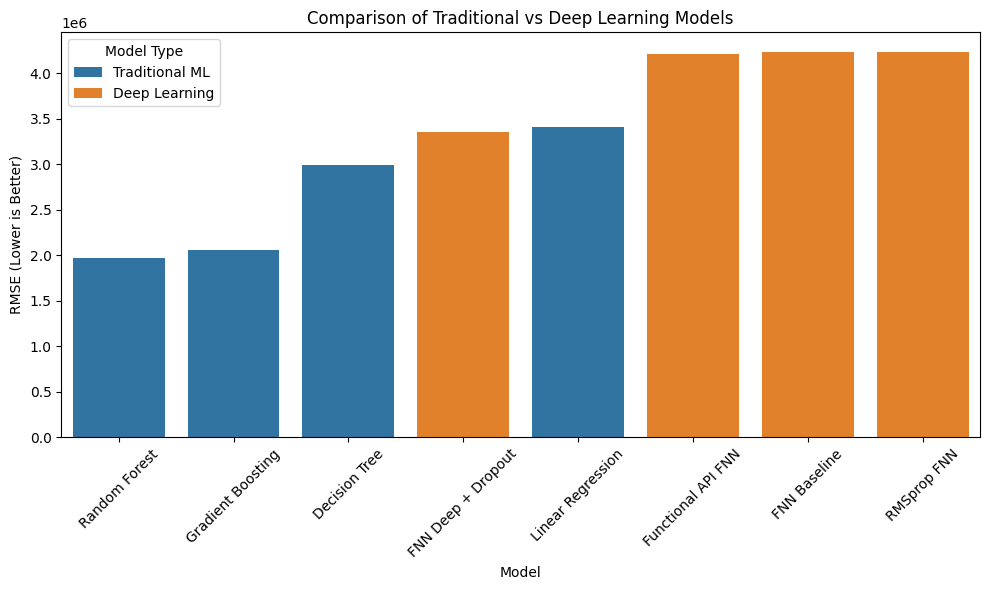

In [32]:
plt.figure(figsize=(10, 6))
sns.barplot(data=final_results, x='Model', y='RMSE', hue='Category')
plt.title("Comparison of Traditional vs Deep Learning Models")
plt.xticks(rotation=45)
plt.ylabel("RMSE (Lower is Better)")
plt.xlabel("Model")
plt.legend(title="Model Type")
plt.tight_layout()
plt.show()
